# Labs 1

## Task1: Generate random numbers
- integer in range [0,5] (using random.integers)
- 100 float random numbers in range [0,5] (using random.uniform)
- 3x3 matrix of floats random number in a range [0,2]
- seed and no seed

no seed

In [50]:
import random

from sympy.stats.sampling.sample_numpy import numpy

rand_int = random.randint(0, 5)

print(rand_int)

rand_float = random.uniform(0, 5)

print(rand_float)

matrix = []
width = 3
height = 3

for x in range(width):
    row = []
    for y in range(height):
        row.append(random.uniform(0, 2))

    matrix.append(row)

print(matrix)

1
2.526776440516812
[[0.05307193936772725, 0.397675301373297, 1.2997688755590464], [1.0898829612064334, 0.4408812440813934, 1.1785313677518174], [1.6188609133556533, 0.012997519356122034, 1.6116385036656158]]


with seed

In [51]:
import random
# with seed
random.seed(42)

rand_int = random.randint(0, 5)

print(rand_int)

rand_float = random.uniform(0, 5)

print(rand_float)

matrix = []
width = 3
height = 3

for x in range(width):
    row = []
    for y in range(height):
        row.append(random.uniform(0, 2))

    matrix.append(row)

print(matrix)

5
0.556655340828402
[[1.4831009995196658, 0.48978370760695245, 0.2790758570502878], [0.204990352343015, 1.4813354893353516, 1.0907330674966995], [1.1809850248980793, 0.06356535896356719, 0.1873904797231849]]


with numpy

In [52]:
import numpy.random as rng
import numpy as np

print(rng.randint(0, 5))

print(rng.uniform(0,2, 100))

print(rng.uniform(0, 2, size=(10,10)))

1
[1.11720559 0.73430179 0.30829746 1.34736315 0.91683828 0.44590335
 0.3742763  0.36811261 0.67531831 1.48999021 0.35278251 0.81923746
 0.61438736 1.78187592 1.90862012 0.8618499  0.24423425 1.39508236
 0.95647567 0.03021237 0.74420919 0.86044359 1.63543432 0.65004012
 0.66086515 0.29273221 1.45505345 1.0683444  0.99658169 1.48479154
 0.38283683 1.6244464  1.65688459 1.15087827 1.22333455 0.35074982
 0.81724222 1.77168952 1.94365631 1.87023503 1.31901552 1.16188672
 0.99818807 0.29776649 1.88753717 1.04258943 0.77785825 0.03584043
 0.06559196 1.73339511 1.20905962 0.27340283 1.36132069 1.36014135
 0.03406154 0.56110221 1.8744363  0.18179996 1.18856019 1.96009699
 1.67196636 1.28474353 1.00028307 1.02697632 0.09691177 1.15008231
 1.63988995 0.89235745 1.14133496 0.55449968 1.42505878 1.79403696
 1.24752998 1.6517061  1.49252505 0.93159653 0.83375297 1.05322249
 0.67252754 1.7622839  0.66670816 1.13083622 1.24456438 1.69996048
 0.8474816  1.7651358  1.70996599 1.177261   0.95638373 0.16

## Calculate $\pi$ using Monte Carlo methods
- The are of a quarter unit circle is $\frac{\pi}{4}$
- The are of unit square is $1 \implies \pi =  4 * \frac{S_{quarter circle}}{S_{square}} \approx 4*\frac{points-in-circle}{total-point-in-square}$

In [53]:
def check_if_inside_circle(x,y):
    if (np.power(x,2) + np.power(y,2)) <= 1:
        return True
    else:
        return False

bins = {"In": 0, "Out": 0}
iters = 100000
for _ in range(iters):
    x,y = np.random.uniform(0, 1, size=2)
    if check_if_inside_circle(x,y):
        bins["In"] += 1
    else:
        bins["Out"] += 1

ratio = 4 * np.divide(bins["In"], bins["In"] + bins["Out"])
print(f"PI number comparison for {iters} iters:\n -estimated:\t{ratio:.8f}\n -true:\t{np.pi:.8f}\nDifference: {np.abs(ratio - np.pi):.8f}")

PI number comparison for 100000 iters:
 -estimated:	3.14484000
 -true:	3.14159265
Difference: 0.00324735


## Task3: Calculate integral using monte carlo
Integration:
$$I = \int_{a}^{b} y(x) dx$$
Monte Carlo Uniform distribution to estimate the integral:
$$\bar{I} = \dfrac{1}{N} \sum_{i=0}^{N-1} I(x_i)= \dfrac{1}{N} \sum_{i=0}^{N-1}(b-a) y(x_i).$$
where $I(x_i) = (b-a)y(x_i)$.

**Standard deviation** of I:
$$ \sigma_{I} =  \sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2}$$
**Standard error** of the estimate:
$$ \sigma_{\bar{I}} =  \dfrac{\sigma_I}{\sqrt{N}}$$
 <!-- $$ \Rightarrow \sigma_{\bar{I}} =  \dfrac{1}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (I(x_i) - \overline{I})^2} =  \dfrac{(b-a)}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (y(x_i) - \overline{y})^2}$$ -->

+	Define a function named **MC_1dim(lower_bound,upper_bound,func,n_points)** to compute the integral of an arbitrary one-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and  the standard error  $\sigma_{\bar{I}}$ , i.e $<I> = \bar{I} \pm \sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi} sin(x) dx$

+	Verify the result by calculating the absolute error: $|\bar{I} - 2|$
+	Analyze the convergence: Change the number of points and plot the absolute error and the Standard error (std) as a function of the number of points using log-log scale. Discussion: How do these errors behave as the number of points increases?
+	Compare the convergence of the Monte Carlo method and the trapezoid (use np.trapezoid()) method by plotting the absolute error of both approaches using log-log scale. Which method converges faster for this one-dimensional integral?
+	How do these method errors scale as O($1/N^{\alpha}$). Compute the slope to find the $\alpha$ value for each method by choosing any 2 pairs $(x_1,y_1), (x_2,y_2)$ from the log-log plot:

	$\alpha = -\dfrac{\log(y_2)-\log(y_1)}{\log(x_2)-\log(x_1)}$

Hint: The expected values are $\alpha_{MC} = 0.5$ and $\alpha_{trapezoid} = 2$.

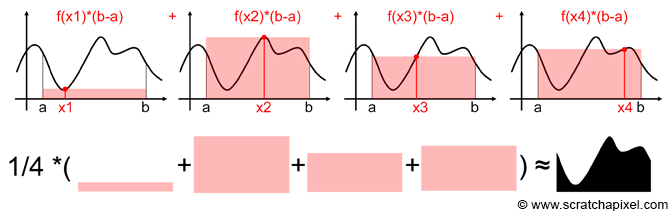

In [54]:
def MC_1dim(lower_bound, upper_bound, func, n_points):
    sum = 0
    points_local = np.random.uniform(lower_bound, upper_bound, size=n_points)

    # calculating the mean
    y_mean_sum = 0
    for x in points_local:
        y = func(x)
        y_mean_sum += y

    y_mean = y_mean_sum / n_points

    # calculating the result
    for x in points_local:
        y = func(x)
        sum += y

    result_local = (upper_bound - lower_bound)/n_points * sum

    # calculating the standard deviation
    error_sum = 0
    for x in points_local:
        error_sum += (func(x) - y_mean) ** 2

    std_error_local = (1/np.sqrt(n_points)) * np.sqrt( (1/(n_points-1)) * error_sum )

    return result_local, std_error_local

points = []

results = []
std_errors = []
abs_errors = []

trap_results = []
std_errors_trap = []
abs_errors_trap = []

range_space = range(10,10000, 10)

for n_point in range_space:
    points.append(n_point)

# monte carlo methods
for n_points in range_space:
    result, std_error = MC_1dim(lower_bound=0, upper_bound=np.pi, func=np.sin, n_points=n_points)

    results.append(result)
    std_errors.append(std_error)
    abs_errors.append(np.abs(result-2))

# trapezoid method
for n_points in range_space:

    x = np.linspace(0, np.pi, num=n_points)
    y = np.sin(x)

    result = np.trapz(y, x)

    trap_results.append(result)
    abs_errors_trap.append(np.abs(result-2))


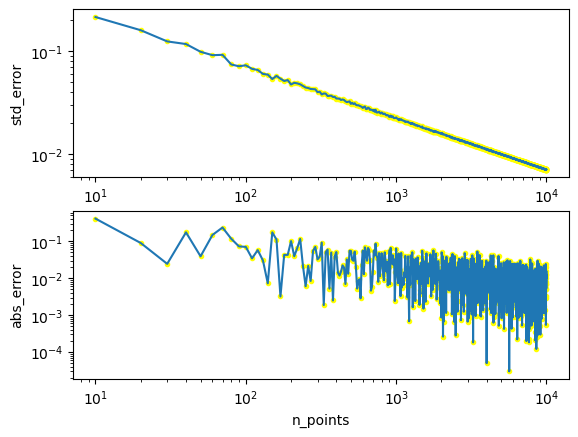

In [55]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(2,1)

# n_point vs std_error
axs[0].scatter(points,std_errors, marker='.', color='yellow')
axs[0].plot(points, std_errors)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('n_points')
axs[0].set_ylabel('std_error')

# n_points vs abs_error
axs[1].scatter(points, abs_errors, marker='.', color='yellow')
axs[1].plot(points, abs_errors)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('n_points')
axs[1].set_ylabel('abs_error')

plt.show()

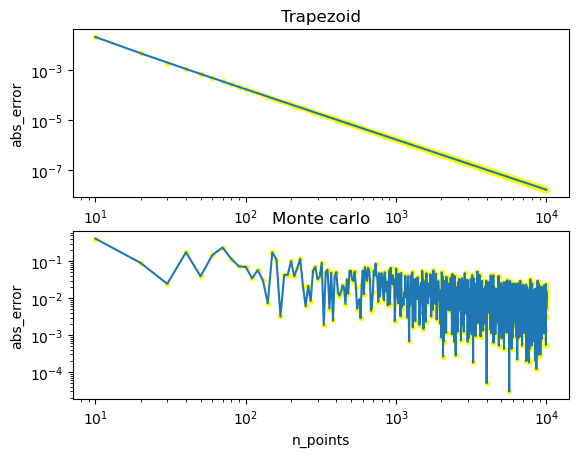

In [56]:
fig, axs = plt.subplots(2,1)

# n_point vs std_error
axs[0].scatter(points,abs_errors_trap, marker='.', color='yellow')
axs[0].plot(points, abs_errors_trap)
axs[0].set_title("Trapezoid")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('n_points')
axs[0].set_ylabel('abs_error')

# n_points vs abs_error
axs[1].scatter(points, abs_errors, marker='.', color='yellow')
axs[1].plot(points, abs_errors)
axs[1].set_title("Monte carlo")
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('n_points')
axs[1].set_ylabel('abs_error')

plt.show()

+	How do these method errors scale as O($1/N^{\alpha}$). Compute the slope to find the $\alpha$ value for each method by choosing any 2 pairs $(x_1,y_1), (x_2,y_2)$ from the log-log plot:

	$\alpha = -\dfrac{\log(y_2)-\log(y_1)}{\log(x_2)-\log(x_1)}$

In [57]:
trapezoid_coeficient = -((np.log(abs_errors_trap[3]) - np.log(abs_errors_trap[4])) / (np.log(points[3]) - np.log(points[4])) )
montecarlo_coeficient = -((np.log(std_errors[3]) - np.log(std_errors[4])) / (np.log(points[3]) - np.log(points[4])) )

print(trapezoid_coeficient, montecarlo_coeficient)

2.0460234929445003 0.7751751254575088


# Task4: Higher dimension integration
In n-dimension

Simple Integration:
$$I = \int_{a}^{b}\int_{a}^{b} ...\int_{a}^{b}dx_1dx_2...dx_n f(x_1,x_2,...,x_n)$$
The estimation value:
$$\bar{I} = (b-a)^n \sum_{i=0}^{N-1} \dfrac{f(x_{1i},x_{2i},...,x_{ni})}{N}.$$
**Standard error** of the estimate:
 $$ \sigma_{\bar{I}} =    \dfrac{(b-a)^n}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (f(x_{1i},x_{2i},...,x_{ni}) - \overline{f})^2}$$

+	Define a function named **MC_ndim(lower,upper,func,n_dims,n_points)** to compute the integral of an arbitrary n-dimensional fucntion using Monte Carlo method. The function should return the integral result $\bar{I}$ and the standard error $\sigma_{\bar{I}}$.
+	Using your function to compute the following integral:

	$I = \int_{0}^{\pi}\int_{0}^{\pi} sin(x_1) sin(x_2) dx_1 dx_2$

+ Compute the above integral for $n_{dims} = 5,7,9$ and plot the absolute values $|\bar{I} - 2^n|$ for these dimension values as a function of n_points using log-log scale. Does the slope of error line change when we increase the dimension ? What is your conclusion ?

In [68]:
def func_sin2dim(x):
    return np.sin(x[0]) * np.sin(x[1])


def MC_ndim(lower,upper,func,n_dims,n_points):
    sum = 0
    points_local = np.random.uniform(lower, upper, size=(n_points, n_dims))

    # calculating the mean
    y_mean_sum = 0
    for x in points_local:
        y = func(x)
        y_mean_sum += y

    y_mean = y_mean_sum / n_points

    # calculating the result
    for x in points_local:
        y = func(x)
        sum += y

    result_local = ((upper - lower)**n_dims) * (sum/n_points)

    # calculating the standard deviation
    error_sum = 0
    for x in points_local:
        error_sum += (func(x) - y_mean) ** 2

    std_error_local = ( ((upper-lower)**n_dims) / np.sqrt(n_points) ) * np.sqrt( (1/(n_points-1)) * error_sum )

    return result_local, std_error_local

In [71]:
points = []

results = {}
std_errors = {}
abs_errors = {}

range_space = range(10,1000, 10)

for n_point in range_space:
    points.append(n_point)

# monte carlo methods
n_dims = [2,5,7,9]
for n_dim in n_dims:
    results[f"{n_dim}"] = []
    std_errors[f"{n_dim}"] = []
    abs_errors[f"{n_dim}"] = []

    for n_points in range_space:
        result, std_error = MC_ndim(lower=0, upper=np.pi, func=func_sin2dim, n_points=n_points, n_dims=n_dim)

        results[f"{n_dim}"].append(result)
        std_errors[f"{n_dim}"].append(std_error)
        abs_errors[f"{n_dim}"].append(np.abs(result-(2**n_dim)))

[[1.10996406 2.58285324]
 [1.46956967 0.22437519]
 [0.30853638 2.5070359 ]
 [0.77128    2.56076913]
 [1.38311003 0.19437318]
 [3.10550306 1.93301084]
 [1.90892776 2.5315946 ]
 [2.16728742 0.87545342]
 [1.24110299 2.98932712]
 [0.23744783 0.48088488]]
[[2.8683432  2.07734699]
 [1.08398091 3.02540037]
 [2.94063894 0.77024303]
 [0.74934531 0.872     ]
 [2.39958639 1.25897967]
 [2.93063687 2.50140011]
 [3.13182257 1.92181994]
 [1.96614286 0.06245759]
 [1.66104113 2.95498684]
 [2.66810091 1.4050757 ]
 [0.68168926 2.69660276]
 [1.29288065 2.250396  ]
 [0.10803736 0.84766644]
 [2.95231119 0.54092848]
 [2.28844246 0.741516  ]
 [1.6387858  1.67459844]
 [2.43360779 1.8740015 ]
 [1.34957757 1.60896073]
 [0.44580429 2.85263437]
 [2.00209401 2.19876718]]
[[3.03810353 0.84163413]
 [0.12552932 1.45894902]
 [0.34907206 2.208881  ]
 [2.55271274 3.03049337]
 [2.15780577 1.31416825]
 [0.81970277 1.86807882]
 [3.1389558  0.47128696]
 [2.97427927 2.87909679]
 [1.34025786 0.2888053 ]
 [2.46885167 2.80408636

In [ ]:
fig, axs = plt.subplots(4,1)

# n_point vs std_error
axs[0].scatter(points,std_errors, marker='.', color='yellow')
axs[0].plot(points, std_errors)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('n_points')
axs[0].set_ylabel('std_error')

**Standard error** of the estimate:
 $$ \sigma_{\bar{I}} =    \dfrac{(b-a)^n}{\sqrt{N}}\sqrt{\dfrac{1}{N-1}\sum_{i=0}^{N-1} (f(x_{1i},x_{2i},...,x_{ni}) - \overline{f})^2}$$
